In [1]:
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from tabpfn import TabPFNRegressor
from sklearn.model_selection import cross_val_score, train_test_split, cross_val_predict, KFold, GroupKFold
import matplotlib.pyplot as plt
import shap
import catboost
from catboost import CatBoostRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

/home/iyar/anaconda3/envs/TabPFN2/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
df = pd.read_excel("Pt_dataset.xlsx")
df_train = pd.read_excel("Pt_dataset.xlsx", sheet_name="Train")
df_test = pd.read_excel("Pt_dataset.xlsx", sheet_name="Test")

In [3]:
def RDkit_descriptors(smiles, suffix=""):
    mols = [Chem.MolFromSmiles(i) for i in smiles] 
    calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
    desc_names = calc.GetDescriptorNames()
    if suffix:
        desc_names = [name + suffix for name in desc_names]
    Mol_descriptors = []
    for mol in mols:
        descriptors = calc.CalcDescriptors(mol)
        Mol_descriptors.append(descriptors)
    return Mol_descriptors, desc_names    

In [4]:
train_descriptors, train_desc_names = RDkit_descriptors(df_train['SMILES'])
RDKit_train = pd.DataFrame(train_descriptors, columns=train_desc_names)

test_descriptors, test_desc_names = RDkit_descriptors(df_test['SMILES'])
RDKit_test = pd.DataFrame(test_descriptors, columns=test_desc_names)

In [5]:
solvent_train_descriptors, solvent_train_desc_names = RDkit_descriptors(df_train['Solvent'], suffix="_sol")
RDKit_train_solvent = pd.DataFrame(solvent_train_descriptors, columns=solvent_train_desc_names)

solvent_test_descriptors, solvent_test_desc_names = RDkit_descriptors(df_test['Solvent'], suffix="_sol")
RDKit_test_solvent = pd.DataFrame(solvent_test_descriptors, columns=solvent_test_desc_names)

In [6]:
def morgan_count_fingerprints(smiles_list, radius=2, n_bits=1024):
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        fp = generator.GetCountFingerprint(mol)
        vec = np.zeros(n_bits, dtype=np.uint16)
        for idx, count in fp.GetNonzeroElements().items():
            vec[idx] = count
        fps.append(vec)
    return pd.DataFrame(fps, columns=[f"morgan_c_{i}" for i in range(n_bits)])

In [7]:
Morgan_train_set = morgan_count_fingerprints(df_train['SMILES'].astype(str).tolist(), radius=2, n_bits=1024)

In [8]:
Morgan_test_set = morgan_count_fingerprints(df_test['SMILES'].astype(str).tolist(), radius=2, n_bits=1024)

In [9]:
df_isomer_train = df_train.iloc[:, -3:]
df_isomer_test = df_test.iloc[:, -3:]

In [10]:
X = pd.concat([df_isomer_train, RDKit_train, RDKit_train_solvent, Morgan_train_set], axis=1)
y = df_train["SH"]

In [11]:
X_var = X.fillna(0)
cb_base = CatBoostRegressor(
    verbose=0    
)

cb_base.fit(X_var, y)



gini_importance = pd.Series(
    cb_base.get_feature_importance(type="FeatureImportance"),
    index=X_var.columns,
    name="gini"
)
explainer = shap.TreeExplainer(cb_base)
shap_values = explainer.shap_values(X_var)

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_var.columns,
    name="shap"
)
pearson_corr = X_var.apply(lambda col: np.corrcoef(col, y)[0, 1])
pearson_corr = pearson_corr.abs()
pearson_corr.name = "pearson"
imp_df = pd.concat(
    [gini_importance, shap_importance, pearson_corr],
    axis=1
)

scaler = MinMaxScaler()
imp_norm = pd.DataFrame(
    scaler.fit_transform(imp_df),
    columns=imp_df.columns,
    index=imp_df.index
)

imp_norm["composite"] = (
    0.4 * imp_norm["gini"] +
    0.4 * imp_norm["shap"] +
    0.2 * imp_norm["pearson"]
)

imp_norm = imp_norm.sort_values("composite", ascending=False)
corr_threshold = 0.98
selected_features = []

corr_matrix = X_var[imp_norm.index].corr().abs()

for feat in imp_norm.index:
    keep = True
    for sel in selected_features:
        if corr_matrix.loc[feat, sel] > corr_threshold:
            keep = False
            break
    if keep:
        selected_features.append(feat)

/home/iyar/anaconda3/envs/TabPFN2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/iyar/anaconda3/envs/TabPFN2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
selected_features_120 = selected_features[:120]
X_120 = X_var[selected_features_120]

In [13]:
X_test = pd.concat([df_isomer_test, RDKit_test, RDKit_test_solvent, Morgan_test_set], axis=1)
X_test = X_test.fillna(0)

X_test_120 = X_test[selected_features_120]

regressor = TabPFNRegressor(n_estimators=32)
regressor.fit(X_120, y)

pred_SH_TAB = regressor.predict(X_test_120.values)

/home/iyar/anaconda3/envs/TabPFN2/lib/python3.11/site-packages/tabpfn/regressor.py:563: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/home/iyar/anaconda3/envs/TabPFN2/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNRegressor was fitted with feature names
  warnings.warn(


In [14]:
def calculate_metrics(y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise ValueError("Arrays must have the same length")
    
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    
    if len(y_true_clean) == 0:
        raise ValueError("No valid data after removing NaN values")
    
    r2 = r2_score(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    
    return r2, rmse, mae

r2, rmse, mae = calculate_metrics(df_test["SH"], pred_SH_TAB)

print("=== Model Performance Metrics ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

=== Model Performance Metrics ===
R² Score: 0.9773
RMSE: 291.3391
MAE: 159.3932


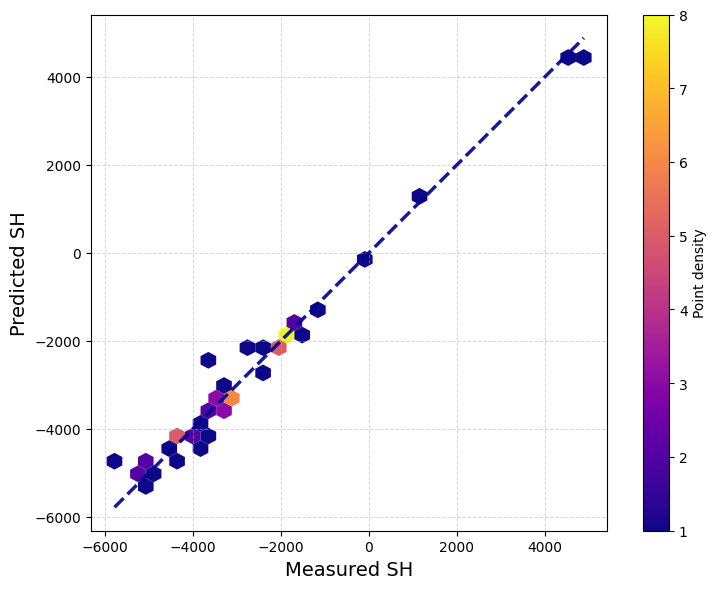

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

hexbin = ax.hexbin(df_test["SH"], pred_SH_TAB, 
                   gridsize=30,
                   cmap='plasma',
                   alpha=1,
                   edgecolors='none',
                   mincnt=1)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Point density', fontsize=10)

y_min, y_max = min(df_test["SH"].min(), pred_SH_TAB.min()), max(df_test["SH"].max(), pred_SH_TAB.max())
ax.plot([y_min, y_max], [y_min, y_max], 
        color='darkblue',
        linestyle='--',
        linewidth=2.5,
        alpha=0.9,
        zorder=2)

ax.set_xlabel("Measured SH", fontsize=14, color='black')
ax.set_ylabel("Predicted SH", fontsize=14, color='black')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.7)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()